# M3 — Квартира проти погоди 🌡️

Проєкт «4331 година» · модуль M3 + додатковий показник **ризик цвілі**.

## Питання

**Як вулиця впливає на квартиру і з якою затримкою?**

Три підпитання:

| # | Питання | Метрика |
|---|---|---|
| 1 | Наскільки дім гасить коливання вулиці? | **згладжування**, разів |
| 2 | На скільки годин дім відстає від вулиці? | **лаг**, годин |
| 3 | +1 °C надворі — це скільки °C вдома? | **чутливість**, OLS |

Плюс: чи комфортно тут жити (20–24 °C, 30–60 % вологості) і чи є **ризик цвілі**.

## Дані

`data/clean/hours_wide.csv` — один рядок на годину (модуль M1): три кімнати
(температура + вологість) і погода Open-Meteo по Харкову.

Важливо: години з прапорцем `stuck` (датчик завис — у житловій кімнаті
144 години поспіль 18–24.08) **виключаємо**. M1 лишив значення на місці,
але для статистики це артефакт, а не факт.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
from IPython.display import Image, display

from src import climate as C

ROOT = pathlib.Path.cwd().parent
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
C.set_style()

df, info = C.load_climate(ROOT)
print(f"годин у таблиці:      {info['rows']}")
print(f"прибрано stuck-годин: {info['stuck_hours_removed']}")
print(f"період (Київ):        {info['ts_start_kyiv'][:16]} — {info['ts_end_kyiv'][:16]}")
info["stuck_removed_by_col"]

годин у таблиці:      4402
прибрано stuck-годин: 384
період (Київ):        2026-03-16 10:00 — 2026-09-15 20:00


{'bedroom_hum': 169,
 'bedroom_temp': 169,
 'kitchen_hum': 23,
 'kitchen_temp': 23,
 'printernya_hum': 0,
 'printernya_temp': 0}

## 1. Описова статистика

Скільки взагалі градусів і відсотків вологості ми бачили.

In [2]:
desc = C.describe_rooms(df)
desc[["room_ua", "metric", "n_hours", "mean", "min", "max", "std"]]

,room_ua,metric,n_hours,mean,min,max,std
0,житлова кімната,температура,4154,24.35,19.16,30.17,2.08
1,житлова кімната,вологість,4154,42.14,22.65,62.42,7.06
2,кухня,температура,2656,25.85,21.70,30.36,1.90
3,кухня,вологість,2656,40.28,21.58,55.34,5.56
4,кладова,температура,3795,27.29,22.16,30.17,2.40
5,кладова,вологість,3795,44.64,33.03,61.49,3.49
6,надворі,температура,4402,16.94,-1.30,36.10,7.73
7,надворі,вологість,4402,62.36,15.00,100.00,20.08


Кладова найтепліша (3D-принтер і NAS гріють її зсередини), надворі розмах —
від мінуса до +36 °C. Вдома такого розмаху немає й близько.

In [3]:
monthly = C.monthly_table(df)
monthly.pivot(index="month", columns="room_ua", values="temp_mean")

room_ua,житлова кімната,кладова,кухня,надворі
month,,,,
2026-03,22.67,NaN,NaN,6.91
2026-04,21.95,23.41,23.45,7.25
2026-05,24.06,25.58,25.56,16.92
2026-06,25.50,28.46,26.99,20.95
2026-07,25.63,28.77,27.50,20.75
2026-08,25.37,29.32,27.85,23.06
2026-09,24.84,28.59,27.05,18.23


In [4]:
monthly.pivot(index="month", columns="room_ua", values="hum_mean")

room_ua,житлова кімната,кладова,кухня,надворі
month,,,,
2026-03,40.89,NaN,NaN,77.90
2026-04,47.56,44.50,43.80,72.77
2026-05,41.56,45.70,40.15,56.95
2026-06,39.96,45.16,38.46,56.83
2026-07,44.55,46.91,41.51,67.34
2026-08,38.79,42.40,36.85,50.43
2026-09,38.54,40.78,36.21,62.10


## 2. Добовий цикл

Середня температура по годині доби (київський час).

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Bedroom,24.0,23.7,23.4,23.2,23.1,23.1,23.6,24.3,24.8,25.2,25.3,25.2,25.2,25.0,24.9,24.8,24.8,24.7,24.7,24.5,24.4,24.2,24.1,24.1
Kitchen,26.0,25.8,25.5,25.2,25.0,24.9,25.0,25.3,25.7,26.0,26.2,26.4,26.4,26.3,26.2,26.2,26.2,26.1,26.1,26.0,26.0,26.0,26.0,26.0
Printernya,27.3,27.3,27.3,27.3,27.3,27.3,27.3,27.3,27.3,27.3,27.4,27.3,27.3,27.3,27.3,27.3,27.2,27.2,27.2,27.3,27.3,27.3,27.3,27.3
Outdoor,14.9,14.3,13.7,13.2,12.7,12.3,12.4,13.4,15.0,16.8,18.3,19.4,20.3,20.8,20.9,21.1,20.8,20.5,19.9,19.0,17.9,17.0,16.3,15.6


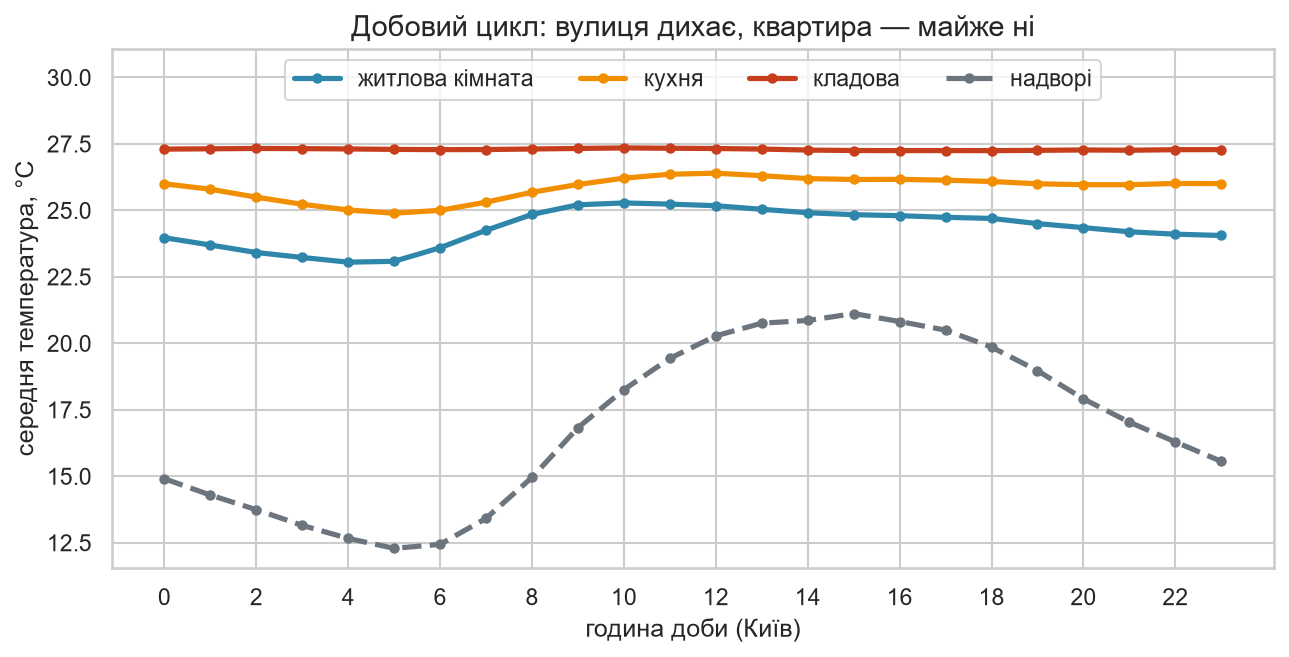

In [5]:
cycle = C.daily_cycle(df)
display(cycle.T.round(1))
display(Image(str(C.plot_daily_cycle(cycle, ROOT))))

Надворі амплітуда добового циклу ≈ 8,8 °C, у житловій кімнаті — 2,2 °C,
у кухні — 1,5 °C, у кладовій — 0,1 °C (пряма лінія).

І головне, що видно на око: **вулиця найтепліша о 15-й, а житлова кімната —
вже о 10-й**. Кімната не відстає від вулиці, а випереджає її. Пояснення просте:
сонце світить у вікно вранці, і кімната гріється від сонця, а не від повітря.

## 3. Згладжування — у скільки разів дім гасить коливання

`згладжування = середній денний перепад надворі / середній денний перепад у кімнаті`.

Перепад рахуємо по київських добах, де є щонайменше 20 годин даних,
і порівнюємо тільки спільні доби (кухня має покриття 68 %).

In [6]:
smooth = C.smoothing(df)
smooth[["room_ua", "n_days", "outdoor_daily_range", "indoor_daily_range", "smoothing_x"]]

,room_ua,n_days,outdoor_daily_range,indoor_daily_range,smoothing_x
0,житлова кімната,167,9.83,3.34,2.94
1,кухня,107,9.73,2.14,4.55
2,кладова,153,10.02,0.67,14.88


Кладова без вікна — термос: гасить коливання майже у 15 разів.
Житлова кімната з вікном — лише втричі.

> Специфікація («вже перевірено») давала 3,1 / 4,7 / 14,2. У нас 2,9 / 4,6 / 14,9 —
> різниця через те, що ми **прибрали 384 застряглі години**, а раніше вони лишалися
> в даних і штучно занижували денні перепади.

## 4. Лаг — на скільки годин дім відстає

### Чому не можна корелювати «як є»

Сирі ряди за пів року містять **сезонний хід**: і вулиця, і кімната монотонно
теплішали з березня до серпня. Через це кореляція буде високою при **будь-якому**
зсуві, і `argmax` покаже випадкове число.

Тому беремо **аномалії** — відхилення від локального добового середнього
(ковзне центроване вікно 24 год). Сезонний хід зникає, лишається добова хвиля,
а нас цікавить саме зсув її фази.

### Одна пастка

Ряд аномалій майже періодичний із періодом 24 год, тому крива крос-кореляції
теж періодична: зсуви 0 і 24 години — це фізично одне й те саме.
Тому зсув `k > 12` читаємо як `k − 24`: **від'ємний лаг = кімната випереджає вулицю**.

Для перевірки рахуємо ще й на **перших різницях** (`diff`) — другим способом.

In [7]:
curves = pd.DataFrame({C.room_ua(r): C.cross_correlation(df, r, 24, "anomaly")
                       for r in C.ROOMS}).round(2)
curves.T

lag_h,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
житлова кімната,0.57,0.44,0.29,0.12,-0.03,-0.16,-0.28,-0.37,-0.45,-0.50,-0.52,-0.51,-0.48,-0.41,-0.31,-0.20,-0.07,0.06,0.20,0.34,0.46,0.55,0.60,0.59,0.53
кухня,0.66,0.60,0.50,0.36,0.22,0.08,-0.06,-0.17,-0.28,-0.36,-0.44,-0.48,-0.51,-0.50,-0.47,-0.41,-0.33,-0.22,-0.08,0.07,0.23,0.39,0.51,0.59,0.61
кладова,0.01,-0.00,-0.03,-0.05,-0.08,-0.09,-0.09,-0.08,-0.06,-0.03,-0.00,0.02,0.04,0.05,0.07,0.07,0.07,0.07,0.06,0.05,0.04,0.02,0.01,-0.00,-0.02


In [8]:
lag = C.lags(df)
lag[["room_ua", "lag_h", "corr_at_lag", "corr_at_0", "lag_identifiable", "lag_h_diff"]]

,room_ua,lag_h,corr_at_lag,corr_at_0,lag_identifiable,lag_h_diff
0,житлова кімната,-2,0.600,0.566,True,-1
1,кухня,0,0.658,0.658,True,0
2,кладова,-8,0.075,0.012,False,0


| Кімната | Лаг | Пік кореляції | Що це означає |
|---|---|---|---|
| житлова кімната | **−2 год** | 0,60 | кімната **випереджає** вулицю — сонце у вікно |
| кухня | **0 год** | 0,66 | йде синхронно з вулицею |
| кладова | — | 0,08 | **лаг не визначається**: добового зв'язку просто немає |

Про кладову чесно: пік кореляції 0,08 — це шум. Кімната без вікна, її температуру
задає 3D-принтер, а не вулиця, тому «лаг 12 годин» зі старого прогону —
артефакт argmax по плоскій кривій, а не фізика. Ми таке пишемо як «не визначено».

## 5. Чутливість — +1 °C надворі = +X °C вдома

Звичайна лінійна регресія (`statsmodels`, OLS).
Рахуємо у двох варіантах:

- **погодинний** — багато точок, але сусідні години сильно залежні;
  тому довірчий інтервал рахуємо з поправкою Ньюї–Веста (HAC, 24 лаги);
- **по добових середніх** — точок менше, зате вони майже незалежні.

In [9]:
sens = C.sensitivity_table(df)
sens[["room_ua", "scope", "n", "slope", "ci_low", "ci_high", "r2"]]

,room_ua,scope,n,slope,ci_low,ci_high,r2
0,житлова кімната,hourly,4154,0.2197,0.2028,0.2367,0.6564
1,житлова кімната,daily,179,0.2265,0.2086,0.2444,0.7792
2,кухня,hourly,2656,0.2168,0.1986,0.2350,0.7000
3,кухня,daily,117,0.2457,0.2216,0.2697,0.7803
4,кладова,hourly,3795,0.2240,0.1985,0.2495,0.4748
5,кладова,daily,163,0.2888,0.2533,0.3242,0.6163


**Чутливість однакова в усіх трьох кімнатах: ≈ +0,22 °C на кожен +1 °C надворі** —
рівно як у специфікації. Довірчі інтервали кімнат перетинаються, тобто різниці між
ними немає.

Більше довіряю **добовому варіанту**: погодинні дані порушують головне припущення
регресії (незалежність спостережень), і навіть із HAC-поправкою похибка там
оптимістична. Добові середні дають той самий нахил (0,23–0,29) і вищий R² (0,62–0,78).

Красива деталь: **згладжування різне (3× проти 15×), а чутливість однакова.**
Інерція кімнати впливає на те, як швидко вона реагує, а не на те, наскільки сильно.

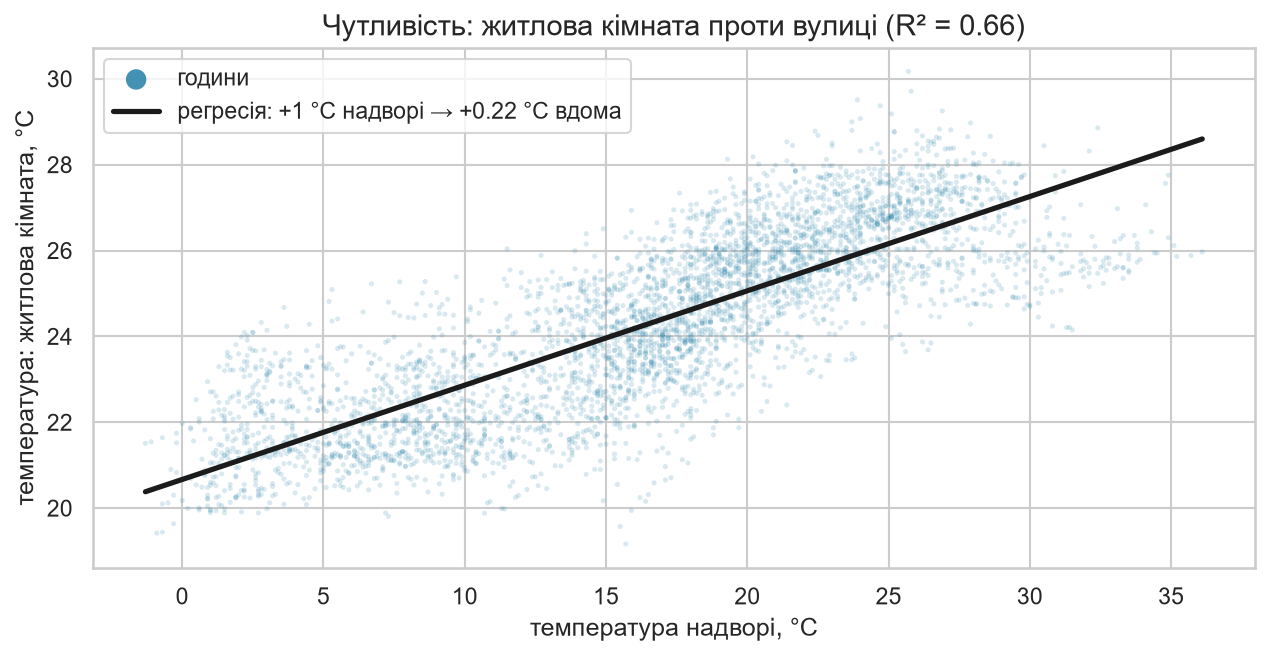

In [10]:
display(Image(str(C.plot_scatter_sensitivity(df, ROOT))))

## 6. Комфорт

Межі зі специфікації: **20–24 °C** і **30–60 % вологості**.

In [11]:
comf = C.comfort(df)
comf[["room_ua", "too_cold_pct", "temp_ok_pct", "too_hot_pct",
      "too_dry_pct", "hum_ok_pct", "too_humid_pct"]]

,room_ua,too_cold_pct,temp_ok_pct,too_hot_pct,too_dry_pct,hum_ok_pct,too_humid_pct
0,житлова кімната,0.5,42.3,57.1,3.8,95.8,0.4
1,кухня,0.0,22.0,78.0,3.2,96.8,0.0
2,кладова,0.0,17.4,82.6,0.0,99.9,0.1


In [12]:
comf_m = C.comfort(df, by_month=True)
comf_m.pivot(index="month", columns="room_ua", values="temp_ok_pct")

room_ua,житлова кімната,кладова,кухня
month,,,
2026-03,94.2,NaN,NaN
2026-04,90.1,76.8,75.6
2026-05,45.1,23.9,14.0
2026-06,20.3,0.0,1.0
2026-07,14.2,0.0,0.0
2026-08,19.0,0.0,0.0
2026-09,28.8,0.0,0.0


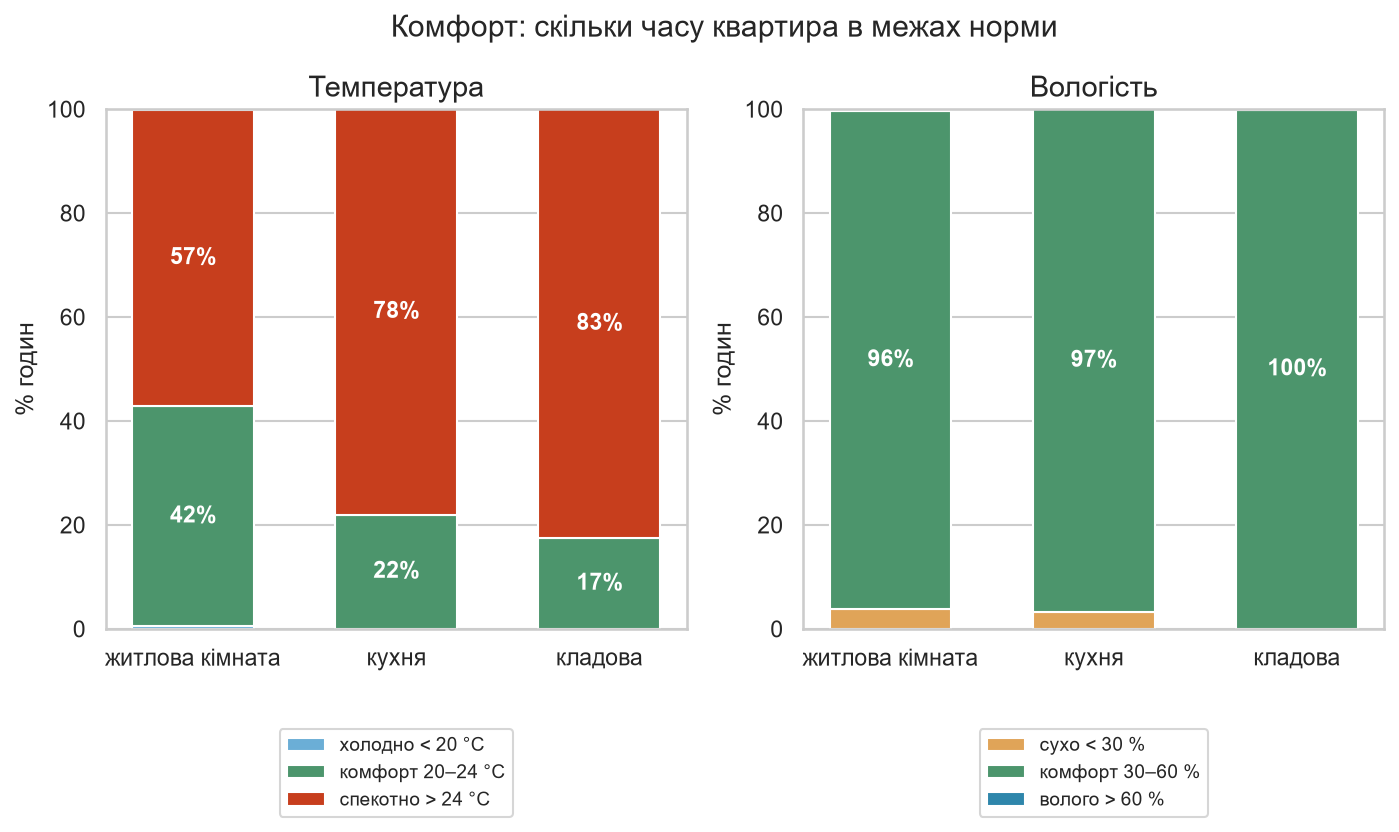

In [13]:
display(Image(str(C.plot_comfort(comf, ROOT))))

Несподіванка: проблема квартири — **не холод, а спека**.
Нижче 20 °C житлова кімната була лише 0,5 % часу, а вище 24 °C — **57 %**.
У кухні 78 %, у кладовій 83 %. З вологістю навпаки — майже ідеально (96–100 % часу в нормі).

## 7. Ризик цвілі 🦠

**Метод.** Точка роси — формула Магнуса:

$$T_d = \frac{b\gamma}{a-\gamma}, \qquad
\gamma = \ln\frac{RH}{100} + \frac{a\,T}{b+T}, \qquad a = 17{,}62,\; b = 243{,}12\;°C$$

**Поріг ризику** (треба назвати явно, бо єдиного стандарту немає):
вологість **≥ 65 %** протягом **≥ 6 годин поспіль**. Одна мокра година після душу —
не ризик; цвіль росте там, де волого **довго**. Розрив у даних розриває серію —
не домальовуємо того, чого не бачили.

In [14]:
mould = C.mould_risk(df)
mould[["room_ua", "n_hours", "hum_mean", "hum_p95", "hum_max",
       "hours_ge_threshold", "risk_hours", "mould_risk_pct"]]

,room_ua,n_hours,hum_mean,hum_p95,hum_max,hours_ge_threshold,risk_hours,mould_risk_pct
0,житлова кімната,4154,42.14,53.60,62.42,0,0,0.0
1,кухня,2656,40.28,49.30,55.34,0,0,0.0
2,кладова,3795,44.64,49.85,61.49,0,0,0.0


In [15]:
mould[["room_ua", "dew_point_mean", "dew_point_max", "dew_margin_mean", "dew_margin_min"]]

,room_ua,dew_point_mean,dew_point_max,dew_margin_mean,dew_margin_min
0,житлова кімната,10.45,17.70,13.90,7.61
1,кухня,11.18,17.10,14.67,9.48
2,кладова,14.15,18.89,13.14,7.97


**Ризик цвілі = 0 %** — в усіх трьох кімнатах, за всі 4402 години.

Вологість **жодного разу** не дійшла до 65 %: максимум за пів року — 62,4 %
у житловій кімнаті, і то одиничні години. Запас до точки роси не падав нижче
**7,6 °C** — щоб почалася конденсація, поверхня мала б бути на 8 градусів
холоднішою за повітря.

Перевіримо, наскільки результат стійкий до вибору порога.

,rh_threshold_pct,bedroom,kitchen,printernya
0,50.0,12.4,2.6,2.7
1,55.0,1.7,0.0,0.2
2,60.0,0.2,0.0,0.0
3,65.0,0.0,0.0,0.0
4,70.0,0.0,0.0,0.0


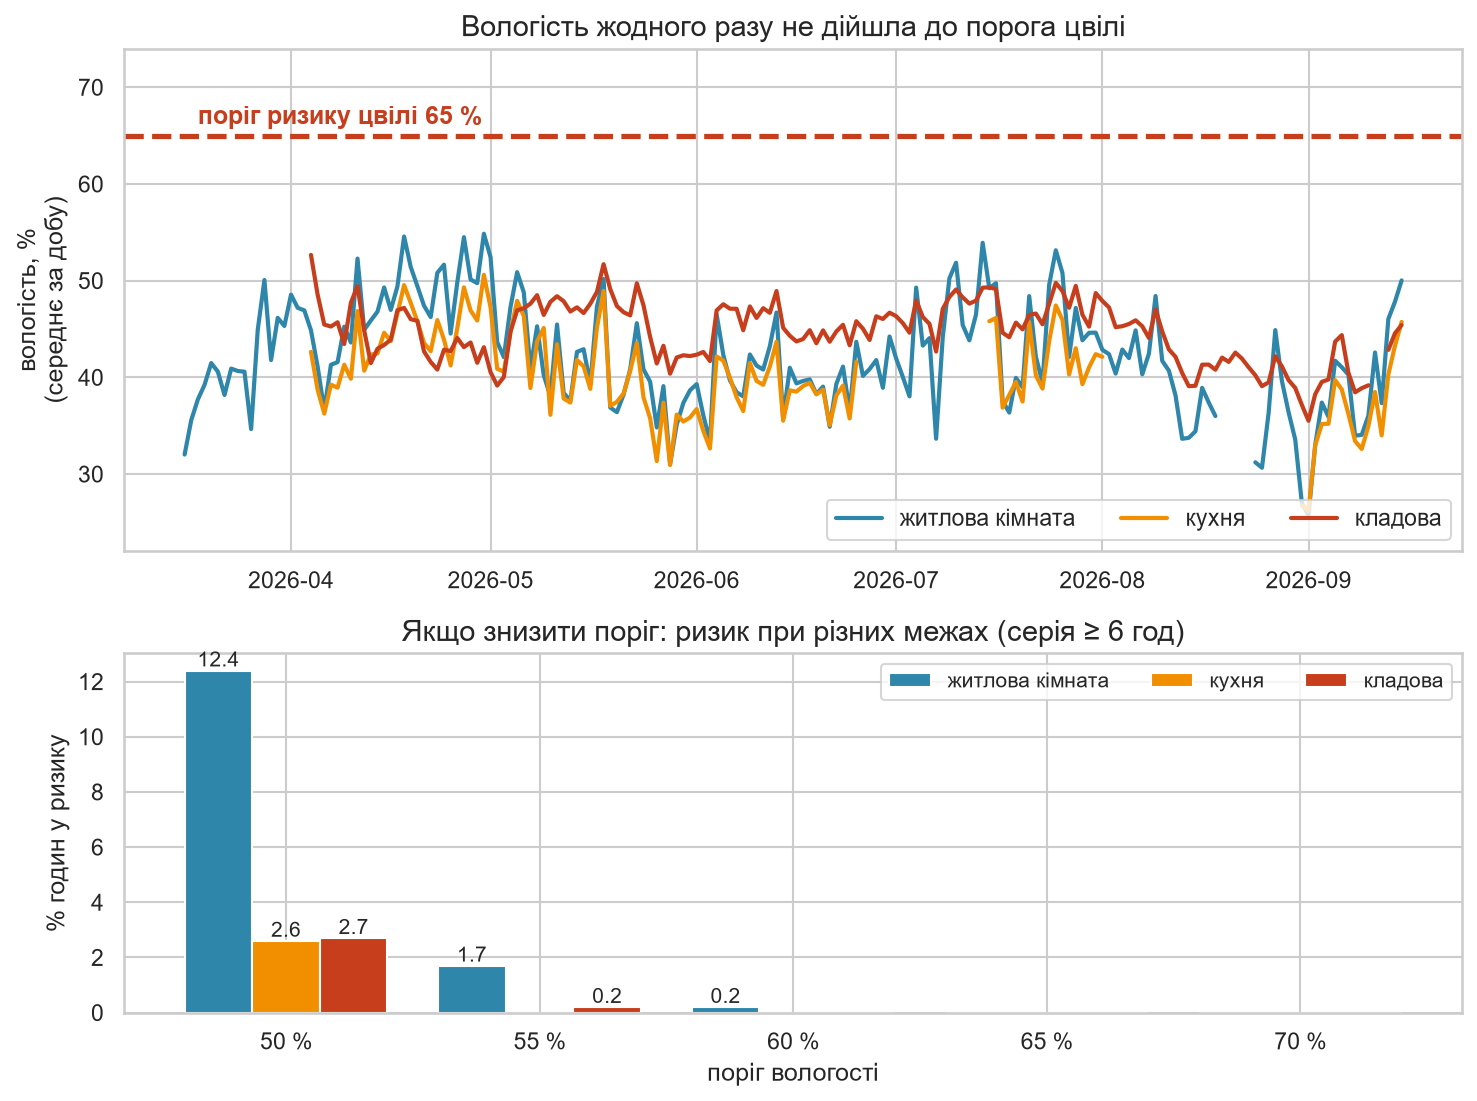

In [16]:
scan = C.mould_threshold_scan(df)
display(scan)
display(Image(str(C.plot_mould(df, scan, ROOT))))

Навіть якщо знизити поріг до 60 %, ризик — 0,2 %; до 55 % — 1,7 %.
Тобто нуль тут не через вдало підібраний поріг.

Чому так: будинок новий, але **пересушений** — влітку працює кондиціонер,
який заодно сушить повітря. Для новобудови це радше добре, ніж погано,
але 3,8 % часу житлова кімната була **сухіша за 30 %** — це вже інша крайність.

## Загальна картина

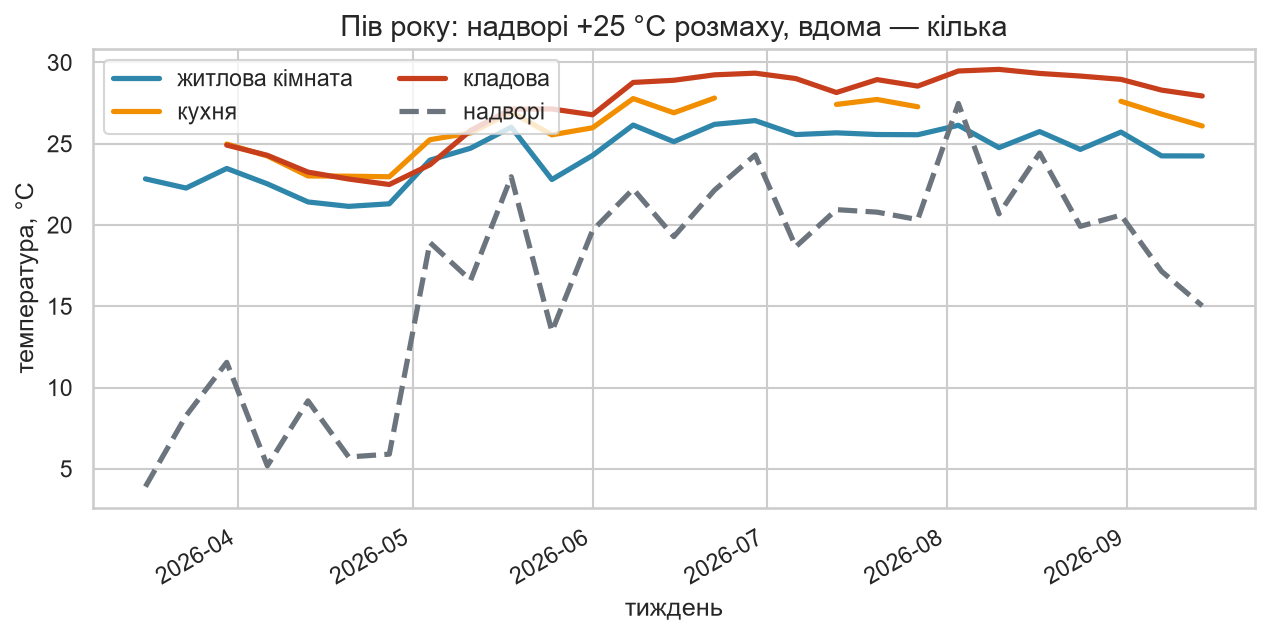

In [17]:
display(Image(str(C.plot_indoor_vs_outdoor(df, ROOT))))

Надворі за пів року — від −1 до +36 °C. Вдома — рівна лінія з повільним підйомом.
Квартира не просто гасить добові стрибки, вона гасить і сезон.

## Збереження результатів

In [18]:
res, tables = C.build_results(df, info)
paths = C.save_results(res, tables, ROOT)
for p in paths:
    print(p.relative_to(ROOT))
print()
for k in ["bedroom_smoothing_x", "bedroom_lag_h", "bedroom_sensitivity", "bedroom_r2",
          "bedroom_comfort_temp_ok_pct", "mould_risk_pct_living_room", "sensitivity_mean"]:
    print(f"{k:32s} {res[k]}")

results\m3_climate.json
results\m3_daily_cycle.csv
results\m3_monthly.csv
results\m3_comfort.csv

bedroom_smoothing_x              2.94
bedroom_lag_h                    -2
bedroom_sensitivity              0.22
bedroom_r2                       0.656
bedroom_comfort_temp_ok_pct      42.3
mould_risk_pct_living_room       0.0
sensitivity_mean                 0.22


## Висновки

- **Згладжування.** Квартира гасить добові коливання вулиці у **2,9 раза**
  (житлова кімната), **4,6 раза** (кухня) і **14,9 раза** (кладова без вікна).
  Надворі середній денний перепад 9,8 °C, у кладовій — 0,7 °C.
- **Лаг.** Кухня йде з вулицею синхронно (0 год), а житлова кімната **випереджає
  вулицю на 2 години**: сонце у вікно гріє її о 10-й, коли повітря надворі ще холодне.
  Для кладової лаг **не визначається** — пік кореляції 0,08, добового зв'язку немає.
- **Чутливість.** +1 °C надворі = **+0,22 °C вдома** — однаково в усіх трьох кімнатах
  (95 % ДІ 0,20–0,25, R² = 0,48–0,70). Інерція у кімнат різна, а чутливість — ні.
- **Комфорт.** Головна проблема — спека, а не холод: житлова кімната була вище 24 °C
  **57 %** часу, а нижче 20 °C — лише 0,5 %. Вологість натомість майже ідеальна:
  **95,8 %** годин у межах 30–60 %.
- **Ризик цвілі = 0 %.** Вологість жодного разу не трималася ≥ 65 % шість годин поспіль;
  максимум за пів року — 62,4 %, запас до точки роси не менший за 7,6 °C.
  Результат стійкий: навіть при порозі 60 % ризик 0,2 %.

## Як сказати на співбесіді за 30 секунд

> Пів року погодинних даних із власної квартири — 4402 години, три кімнати проти погоди
> з Open-Meteo. Порахувала три речі: квартира гасить добові коливання вулиці
> від 3 до 15 разів залежно від кімнати, а чутливість скрізь однакова —
> +1 °C надворі дає +0,22 °C вдома, R² 0,66. Найцікавіше вилізло на лагу:
> житлова кімната не відстає від вулиці, а **випереджає** її на дві години —
> сонце б'є у вікно о 10-й, коли повітря надворі ще холодне. Ризик цвілі
> порахувала через точку роси за формулою Магнуса: **0 %**, вологість жодного разу
> не трималася вище 65 % шість годин поспіль. І окремо чесний момент — там, де
> кореляція виявилася 0,08, я не стала витягувати «лаг 12 годин», а написала
> «не визначається».